In [21]:
import sys
sys.path.append('../scripts')
import waveguise_3d as three
sys.path.append('/home/r/Robert.Reichert/sexy-wave')
import plotting_cosmetics as pc

import datetime
import matplotlib.dates as mdates

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import pylops

plt.style.use("../latex_default_AMT.mplstyle")

In [3]:
data_path = '../data/AMTM_recon_fast.nc'
ds_fast = xr.open_dataset(data_path)

data_path = '../data/AMTM_recon_KHI.nc'
ds_KHI = xr.open_dataset(data_path)

data_path = '../data/AMTM_recon_noise.nc'
ds_noise = xr.open_dataset(data_path)

data_path = '../data/AMTM_recon_strong.nc'
ds_strong = xr.open_dataset(data_path)

data_path = '../data/AMTM_recon_big.nc'
ds_big = xr.open_dataset(data_path)

data_path = '/project/meteo/work/Robert.Reichert/data/AMTM/Rio_Grande/2018/201805/AMTM_BI_20180516-2137.nc'
ds_orig = xr.open_dataset(data_path)

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
BI = ds_orig['band intensity'].isel(time=slice(100,255),x=slice(3,-40),y=slice(35,-42))
BI_high = BI.values
BI_high = np.flip(BI_high,axis=0)
BI_high, _ = three.BG_removal(BI_high,max_order=1,fourier_radius=1)

dx, dy, dt = 625, 625, 35
nx, ny, nt = BI['y'].size, BI['x'].size, BI['time'].size
print(nx, ny, nt)

nmask = (ny, nx, nt)
ntap = (20,20,5)
tap3d = pylops.utils.tapers.tapernd(nmask, ntap, "hanning")
new_data = BI_high*tap3d

243 213 155


In [6]:
ds_KHI

<xarray.Dataset> Size: 32MB
Dimensions:   (x: 243, y: 213, time: 155)
Coordinates:
  * x         (x) float64 2kB 21.94 22.57 23.2 23.82 ... 171.8 172.4 173.0 173.7
  * y         (y) float64 2kB 1.882 2.51 3.137 3.765 ... 133.0 133.6 134.3 134.9
  * time      (time) datetime64[ns] 1kB 2018-05-16T22:35:09.999600 ... 2018-0...
Data variables:
    BI_recon  (x, y, time) float32 32MB ...

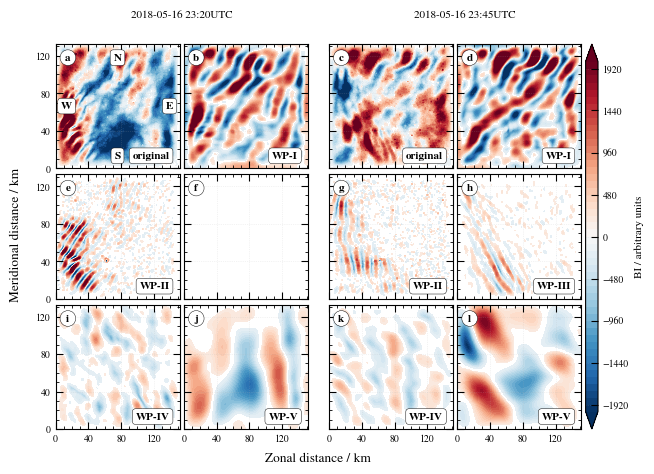

In [13]:
BI_lev = np.linspace(-2000,2000,51)
nx, ny = len(ds_fast.x), len(ds_fast.y)
dx, dy = 625, 625
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 0.1, 1, 1, 0.1], "height_ratios": [1, 1, 1]}

time1='20180516T2320'
time_idx1 = 78
time2='20180516T2345'
time_idx2 = 121

fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(3, 6, **gskw)
ax = np.empty((3, 6), dtype=object)

limit = 160
# TIME 1
ax[0,0] = fig.add_subplot(gs[0, 0])
masked = np.ma.masked_inside(new_data[:,:,time_idx1], -limit, limit)  
ax[0,0].contourf(x,y,masked,levels=np.linspace(-4000,4000,51),extend='both',cmap='RdBu_r')
ax[0,1] = fig.add_subplot(gs[0, 1])
masked = np.ma.masked_inside(ds_strong['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[0,1].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[1,0] = fig.add_subplot(gs[1, 0])
masked = np.ma.masked_inside(ds_KHI['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[1,0].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[1,1] = fig.add_subplot(gs[1, 1])
masked = np.ma.masked_inside(ds_fast['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[1,1].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[2,0] = fig.add_subplot(gs[2, 0])
masked = np.ma.masked_inside(ds_noise['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[2,0].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[2,1] = fig.add_subplot(gs[2, 1])
masked = np.ma.masked_inside(ds_big['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[2,1].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

ax[0,3] = fig.add_subplot(gs[0, 3])
masked = np.ma.masked_inside(new_data[:,:,time_idx2], -limit, limit)  
ax[0,3].contourf(x,y,masked,levels=np.linspace(-4000,4000,51),extend='both',cmap='RdBu_r')
ax[0,4] = fig.add_subplot(gs[0, 4])
masked = np.ma.masked_inside(ds_strong['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[0,4].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[1,3] = fig.add_subplot(gs[1, 3])
masked = np.ma.masked_inside(ds_KHI['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[1,3].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[1,4] = fig.add_subplot(gs[1, 4])
masked = np.ma.masked_inside(ds_fast['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[1,4].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[2,3] = fig.add_subplot(gs[2, 3])
masked = np.ma.masked_inside(ds_noise['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[2,3].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
ax[2,4] = fig.add_subplot(gs[2, 4])
masked = np.ma.masked_inside(ds_big['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
plot_field = ax[2,4].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

cax = fig.add_subplot(gs[:, 5])
cbar = fig.colorbar(plot_field,cax=cax,orientation='vertical',pad=0.05,label='BI / arbitrary units',spacing='uniform')

label=['a','b','','c','d','',
       'e','f','','g','h','',
       'i','j','','k','l','']

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        if (j == 2) or (j == 5):
            continue

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        # y-Ticklabels nur in der linken Spalte
        if j > 0:
            ax[i, j].tick_params(labelleft=False)
        # x-Ticklabels nur in der unteren Zeile
        if i < 2:
            ax[i, j].tick_params(labelbottom=False)

        ax[i,j].text(0.1, 0.89, label[i*ax.shape[1]+j], va='center', ha='center', transform=ax[i,j].transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

ax[0,0].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[0,0].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[0,0].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[0,0].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

ax[0,0].text(0.92, 0.1, 'original', verticalalignment='center', horizontalalignment='right', transform=ax[0,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[0,3].text(0.92, 0.1, 'original', verticalalignment='center', horizontalalignment='right', transform=ax[0,3].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[0,1].text(0.92, 0.1, 'WP-I', verticalalignment='center', horizontalalignment='right', transform=ax[0,1].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[0,4].text(0.92, 0.1, 'WP-I', verticalalignment='center', horizontalalignment='right', transform=ax[0,4].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[1,0].text(0.92, 0.1, 'WP-II', verticalalignment='center', horizontalalignment='right', transform=ax[1,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[1,3].text(0.92, 0.1, 'WP-II', verticalalignment='center', horizontalalignment='right', transform=ax[1,3].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[1,4].text(0.92, 0.1, 'WP-III', verticalalignment='center', horizontalalignment='right', transform=ax[1,4].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[2,0].text(0.92, 0.1, 'WP-IV', verticalalignment='center', horizontalalignment='right', transform=ax[2,0].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[2,3].text(0.92, 0.1, 'WP-IV', verticalalignment='center', horizontalalignment='right', transform=ax[2,3].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[2,1].text(0.92, 0.1, 'WP-V', verticalalignment='center', horizontalalignment='right', transform=ax[2,1].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
ax[2,4].text(0.92, 0.1, 'WP-V', verticalalignment='center', horizontalalignment='right', transform=ax[2,4].transAxes, 
                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

fig.text(0.305, 0.93, "2018-05-16 23:20UTC",  ha="center", va="bottom")# fontsize=12)
fig.text(0.71, 0.93, "2018-05-16 23:45UTC", ha="center", va="bottom")#, fontsize=12)

plt.savefig('./figures/AMTM_two_snapshots_v2.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

In [ ]:
BI_lev = np.linspace(-3000,3000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1, 0.1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,155,16)
fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(4, 5, **gskw)
ax = np.empty((4, 4), dtype=object)

for i in range(4):
    for j in range(4):
        ax[i, j] = fig.add_subplot(gs[i, j])
        plot_field = ax[i,j].contourf(x,y,airglow[:,:,int(time_indexes[i*4+j])],levels=BI_lev,extend='both',cmap=nlc)
        # y-Ticklabels nur in der linken Spalte
        if j > 0:
            ax[i, j].tick_params(labelleft=False)
        # x-Ticklabels nur in der unteren Zeile
        if i < 3:
            ax[i, j].tick_params(labelbottom=False)
            
cax = fig.add_subplot(gs[:, 4])
cbar = fig.colorbar(plot_field,cax=cax,orientation='vertical',pad=0.05,label='BI / arbitrary units',spacing='uniform')

for i in range(4):
    for j in range(4):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.89, str(BI['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

plt.savefig('./figures/AMTM_overview.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

In [4]:
data_path = '../data/fast_WP_properties.nc'
WP_fast = xr.open_dataset(data_path)
data_path = '../data/KHI_WP_properties.nc'
WP_KHI = xr.open_dataset(data_path)
data_path = '../data/strong_WP_properties.nc'
WP_strong = xr.open_dataset(data_path)
data_path = '../data/noise_WP_properties.nc'
WP_noise = xr.open_dataset(data_path)
data_path = '../data/big_WP_properties.nc'
WP_big = xr.open_dataset(data_path)

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/scratch-local/slurm-job-tmp-15890174/ipykernel_2052/3313715797.py:3: SyntaxWarning: invalid escape sequence '\o'
  y_labels = ['Amp / BI units', '$\omega$ / s$^{-1}$', '$\lambda_h$ / km', 'prop direction']
/scratch-local/slurm-job-tmp-15890174/ipykernel_2052/3313715797.py:3: SyntaxWarning: invalid escape sequence '\l'
  y_labels = ['Amp / BI units', '$\omega$ / s$^{-1}$', '$\lambda_h$ / km', 'prop direction']


Text(0.5, 0, 'Time / UTC')

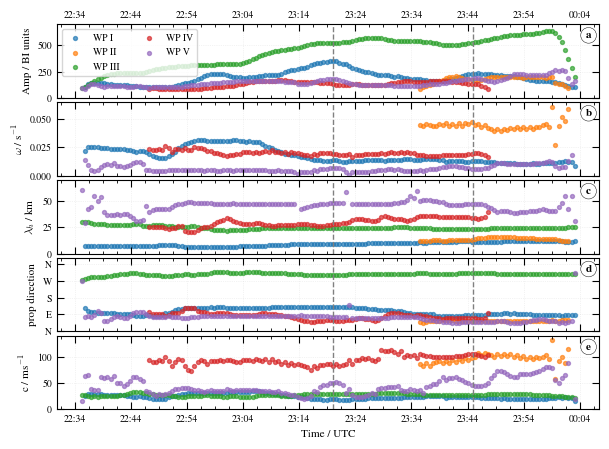

In [41]:
WPs = [WP_KHI,WP_fast,WP_strong,WP_noise,WP_big]
variables = ['amplitude','frequency','wavelength','orientation']
y_labels = ['Amp / BI units', '$\omega$ / s$^{-1}$', '$\lambda_h$ / km', 'prop direction']
y_lims = [[0,700],[0,0.065],[0,70],[0,390]]
label = ['a','b','c','d','e']
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']

gskw = {"hspace": 0.06, "wspace": 0.05, "width_ratios": [1], "height_ratios": [1,1,1,1,1]}
WP_label = ['WP I', 'WP II', 'WP III', 'WP IV', 'WP V']

fig, axes = plt.subplots(5, 1, figsize=(7, 5), sharex=True, gridspec_kw=gskw) 

for i in range(4):
    for j in range(5):
        if variables[i] == 'wavelength':
            axes[i].scatter(WPs[j].time,WPs[j][variables[i]]*1e-3,s=8,alpha=0.67,label=WP_label[j],c=colors[j])
        if variables[i] == 'orientation':
            axes[i].scatter(WPs[j].time,np.rad2deg(WPs[j][variables[i]]),s=8,alpha=0.67,label=WP_label[j],c=colors[j])
        else:
            axes[i].scatter(WPs[j].time,WPs[j][variables[i]],s=8,alpha=0.67,label=WP_label[j],c=colors[j])
    axes[i].set_ylabel(y_labels[i])
    axes[i].set_ylim(y_lims[i])
    axes[i].text(0.98,0.85,label[i], va='center', ha='center', transform=axes[i].transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
    axes[i].axvline(x=datetime.datetime(2018,5,16,23,20),ls='--',c='grey')
    axes[i].axvline(x=datetime.datetime(2018,5,16,23,45),ls='--',c='grey')

axes[3].set_yticks([0,90,180,270,360],labels=['N','E','S','W','N'])
axes[0].legend(ncols=2)

KHI_c=WP_KHI['wavelength']*WP_KHI['frequency']/2/np.pi
fast_c=WP_fast['wavelength']*WP_fast['frequency']/2/np.pi
strong_c=WP_strong['wavelength']*WP_strong['frequency']/2/np.pi
noise_c=WP_noise['wavelength']*WP_noise['frequency']/2/np.pi
big_c=WP_big['wavelength']*WP_big['frequency']/2/np.pi

axes[4].scatter(WP_KHI.time,np.abs(KHI_c),s=8,alpha=0.67)
axes[4].scatter(WP_fast.time,np.abs(fast_c),s=8,alpha=0.67)
axes[4].scatter(WP_strong.time,np.abs(strong_c),s=8,alpha=0.67)
axes[4].scatter(WP_noise.time,np.abs(noise_c),s=8,alpha=0.67)
axes[4].scatter(WP_big.time,np.abs(big_c),s=8,alpha=0.67)
axes[4].set_ylabel('c / ms$^{-1}$')
axes[4].set_ylim([0,140])
axes[4].text(0.98,0.85,'e', va='center', ha='center', transform=axes[4].transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

minlocator = mdates.MinuteLocator(interval=10)
axes[0].xaxis.set_major_locator(minlocator)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[0].xaxis.set_minor_locator(AutoMinorLocator())

axes[0].tick_params(which="both", labelbottom=False, labeltop=True)
axes[4].axvline(x=datetime.datetime(2018,5,16,23,20),ls='--',c='grey')
axes[4].axvline(x=datetime.datetime(2018,5,16,23,45),ls='--',c='grey')

axes[4].set_xlabel('Time / UTC')

#plt.savefig('./figures/AMTM_spectral_properties_v2.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

'\nmasked = np.ma.masked_inside(ds_KHI[\'BI_recon\'].sel(time=time1,method=\'nearest\'), -limit, limit)  \nax[1,0].contourf(x,y,masked.T,levels=BI_lev,extend=\'both\',cmap=\'RdBu_r\')\nmasked = np.ma.masked_inside(ds_fast[\'BI_recon\'].sel(time=time1,method=\'nearest\'), -limit, limit)  \nax[1,1].contourf(x,y,masked.T,levels=BI_lev,extend=\'both\',cmap=\'RdBu_r\')\nmasked = np.ma.masked_inside(ds_noise[\'BI_recon\'].sel(time=time1,method=\'nearest\'), -limit, limit)  \nax[2,0].contourf(x,y,masked.T,levels=BI_lev,extend=\'both\',cmap=\'RdBu_r\')\nmasked = np.ma.masked_inside(ds_big[\'BI_recon\'].sel(time=time1,method=\'nearest\'), -limit, limit)  \nax[2,1].contourf(x,y,masked.T,levels=BI_lev,extend=\'both\',cmap=\'RdBu_r\')\n\nmasked = np.ma.masked_inside(new_data[:,:,time_idx2], -limit, limit)  \nax[0,2].contourf(x,y,masked,levels=np.linspace(-4000,4000,51),extend=\'both\',cmap=\'RdBu_r\')\nmasked = np.ma.masked_inside(ds_strong[\'BI_recon\'].sel(time=time2,method=\'nearest\'), -limit,

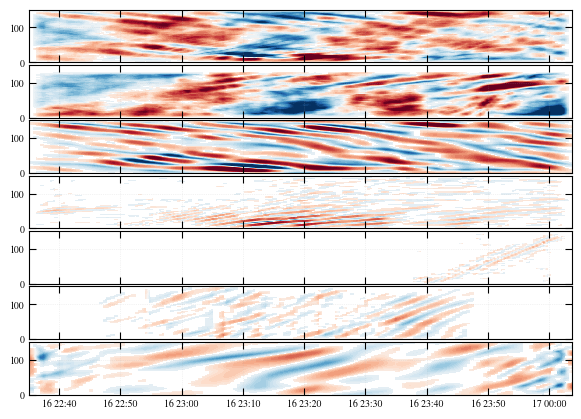

In [33]:
BI_lev = np.linspace(-2000,2000,51)
nx, ny = len(ds_fast.x), len(ds_fast.y)
dx, dy = 625, 625
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1], "height_ratios": [1, 1, 1, 1, 1, 1, 1]}

fig, ax=plt.subplots(7,1, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

x_idx = 121
y_idx = 106

limit = 160
# TIME 1
masked = np.ma.masked_inside(new_data[y_idx,:,:], -limit, limit)  
ax[0].contourf(ds_fast.time,x,masked,levels=np.linspace(-4000,4000,51),extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(new_data[:,x_idx,:], -limit, limit)  
ax[1].contourf(ds_fast.time,y,masked,levels=np.linspace(-4000,4000,51),extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(ds_strong['BI_recon'].isel(y=y_idx), -limit, limit)  
ax[2].contourf(ds_strong.time,x,masked,levels=BI_lev,extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(ds_KHI['BI_recon'].isel(y=y_idx), -limit, limit)  
ax[3].contourf(ds_strong.time,x,masked,levels=BI_lev,extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(ds_fast['BI_recon'].isel(y=y_idx), -limit, limit)  
ax[4].contourf(ds_strong.time,x,masked,levels=BI_lev,extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(ds_noise['BI_recon'].isel(y=y_idx), -limit, limit)  
ax[5].contourf(ds_strong.time,x,masked,levels=BI_lev,extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(ds_big['BI_recon'].isel(y=y_idx), -limit, limit)  
ax[6].contourf(ds_strong.time,x,masked,levels=BI_lev,extend='both',cmap='RdBu_r')
"""
masked = np.ma.masked_inside(ds_KHI['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[1,0].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_fast['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[1,1].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_noise['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[2,0].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_big['BI_recon'].sel(time=time1,method='nearest'), -limit, limit)  
ax[2,1].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

masked = np.ma.masked_inside(new_data[:,:,time_idx2], -limit, limit)  
ax[0,2].contourf(x,y,masked,levels=np.linspace(-4000,4000,51),extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_strong['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[0,3].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_KHI['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[1,2].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_fast['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[1,3].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_noise['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[2,2].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')
masked = np.ma.masked_inside(ds_big['BI_recon'].sel(time=time2,method='nearest'), -limit, limit)  
ax[2,3].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        #ax[i,j].text(0.97, 0.89, str(ds_fast['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
        #                                weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

fig.text(0.305, 0.93, "2018-05-16 23:20UTC",  ha="center", va="bottom")# fontsize=12)
fig.text(0.71, 0.93, "2018-05-16 23:45UTC", ha="center", va="bottom")#, fontsize=12)

plt.savefig('./figures/AMTM_two_snapshots.png', dpi=300, bbox_inches="tight", pad_inches=0.03)
"""

Text(0.5, 0.04, 'Zonal distance / km')

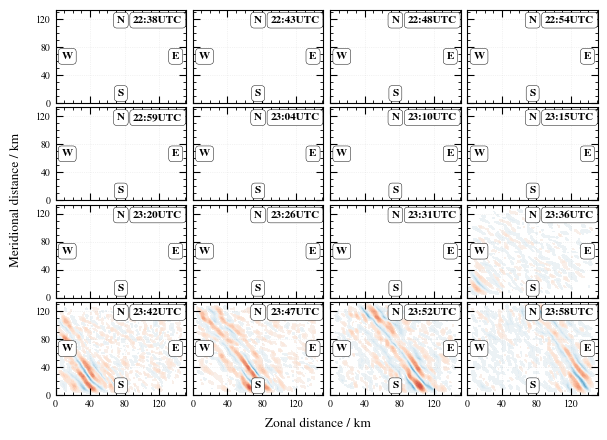

In [4]:
BI_lev = np.linspace(-2000,2000,51)
nx, ny = len(ds_fast.x), len(ds_fast.y)
dx, dy = 625, 625
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,145,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        masked = np.ma.masked_inside(ds_fast['BI_recon'][:,:,int(time_indexes[i*ax.shape[1]+j])], -80, 80)  
        ax[i,j].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.89, str(ds_fast['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

#plt.savefig('./figures/AMTM_KHI.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

Text(0.5, 0.04, 'Zonal distance / km')

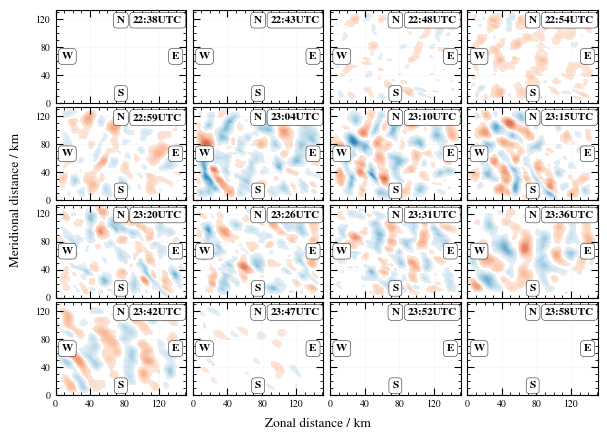

In [57]:
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,145,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        masked = np.ma.masked_inside(ds_noise[:,:,int(time_indexes[i*ax.shape[1]+j])], -200, 200)  
        ax[i,j].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.89, str(ds_fast['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

#plt.savefig('./figures/AMTM_KHI.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

Text(0.5, 0.04, 'Zonal distance / km')

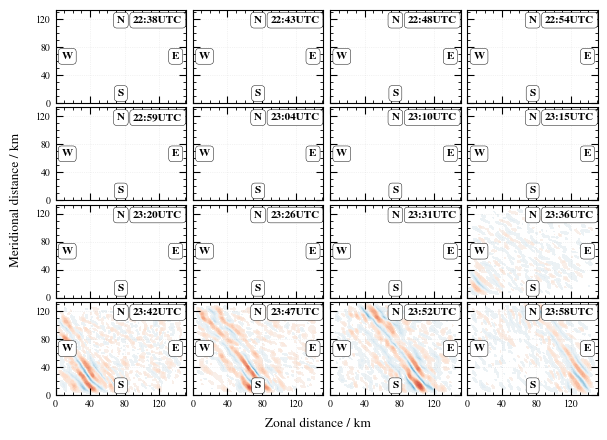

In [4]:
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,145,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        masked = np.ma.masked_inside(ds_fast['recon_WP1'][:,:,int(time_indexes[i*ax.shape[1]+j])], -80, 80)  
        ax[i,j].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.89, str(ds_fast['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

#plt.savefig('./figures/AMTM_KHI.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

Text(0.5, 0.04, 'Zonal distance / km')

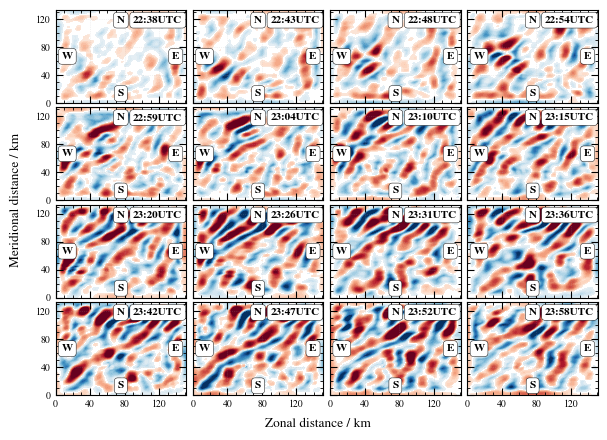

In [59]:
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,145,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        masked = np.ma.masked_inside(ds_6['recon_WP6'][:,:,int(time_indexes[i*ax.shape[1]+j])], -200, 200)  
        ax[i,j].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.89, str(ds_fast['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

#plt.savefig('./figures/AMTM_KHI.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

Text(0.5, 0.04, 'Zonal distance / km')

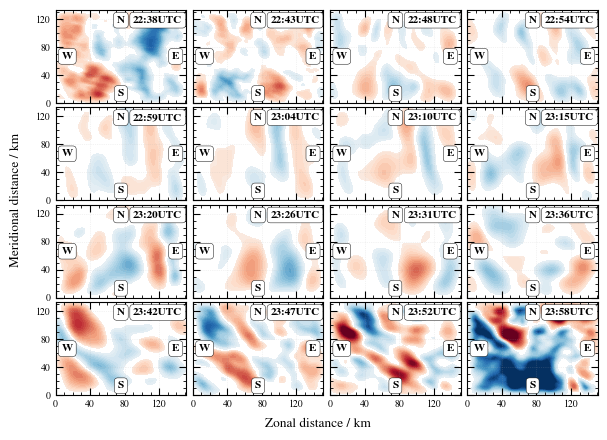

In [60]:
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,145,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        masked = np.ma.masked_inside(ds_7['recon_WP7'][:,:,int(time_indexes[i*ax.shape[1]+j])], -200, 200)  
        ax[i,j].contourf(x,y,masked.T,levels=BI_lev,extend='both',cmap='RdBu_r')

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):

        ax[i,j].yaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(40))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())

        ax[i,j].text(0.5, 0.89, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.1, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.09, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.92, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.89, str(ds_fast['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.33, "facecolor":"white", "edgecolor":"black"})

fig.supylabel("Meridional distance / km", x=0.06)
fig.supxlabel("Zonal distance / km", y=0.04)

#plt.savefig('./figures/AMTM_KHI.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

Text(0, 0.5, 'Phase speed / ms$^{-1}$')

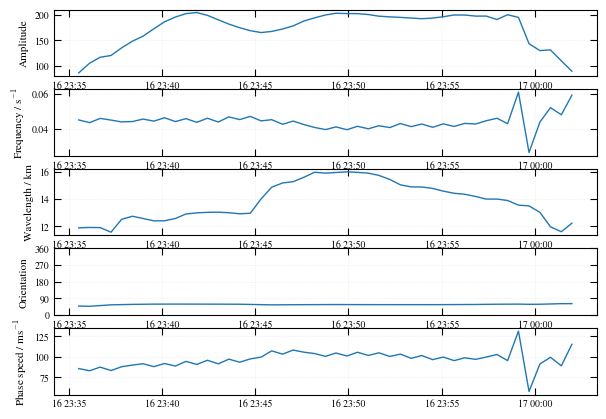

In [15]:
fig=plt.figure(figsize=(7,5))

ax=fig.add_subplot(511)
#ax.plot(ds_KHI.time,ds_KHI['amplitude'],label='WP I')
ax.plot(ds_fast.time,ds_fast['amplitude'], label='WP2')
#ax.plot(ds_strong.time,ds_strong['amplitude'])
#ax.plot(ds_noise.time,ds_noise['amplitude'])
#ax.plot(ds_big.time,ds_big['amplitude'])
ax.set_ylabel('Amplitude')
#ax.set_ylim([0,500])

ax=fig.add_subplot(512)
#ax.plot(ds_KHI.time,ds_KHI['frequency'])
ax.plot(ds_fast.time,np.abs(ds_fast['frequency']))
#ax.plot(ds_strong.time,np.abs(ds_strong['frequency']))
#ax.plot(ds_noise.time,ds_noise['frequency'])
#ax.plot(ds_big.time,ds_big['frequency'])
ax.set_ylabel('Frequency / s$^{-1}$')

ax=fig.add_subplot(513)
#ax.plot(ds_KHI.time,ds_KHI['wavelength']*1e-3)
ax.plot(ds_fast.time,ds_fast['wavelength']*1e-3)
#ax.plot(ds_strong.time,ds_strong['wavelength']*1e-3)
#ax.plot(ds_noise.time,ds_noise['wavelength']*1e-3)
#ax.plot(ds_big.time,ds_big['wavelength']*1e-3)
ax.set_ylabel('Wavelength / km')

ax=fig.add_subplot(514)
#ax.plot(ds_KHI.time,np.rad2deg(ds_KHI['orientation']))
ax.plot(ds_fast.time,np.rad2deg(ds_fast['orientation']))
#ax.plot(ds_strong.time,np.rad2deg(ds_strong['orientation']))
#ax.plot(ds_noise.time,np.rad2deg(ds_noise['orientation']))
ax.set_ylabel('Orientation')
ax.set_ylim([0,360])
ax.set_yticks([0,90,180,270,360])

#KHI_c=ds_KHI['wavelength']*ds_KHI['frequency']/2/np.pi
fast_c=ds_fast['wavelength']*ds_fast['frequency']/2/np.pi
#strong_c=ds_strong['wavelength']*ds_strong['frequency']/2/np.pi
#noise_c=ds_noise['wavelength']*ds_noise['frequency']/2/np.pi

ax=fig.add_subplot(515)
#ax.plot(ds_KHI.time,KHI_c)
ax.plot(ds_fast.time,np.abs(fast_c))
#ax.plot(ds_strong.time,np.abs(strong_c))
#ax.plot(ds_noise.time,np.abs(noise_c))
ax.set_ylabel('Phase speed / ms$^{-1}$')